# Football Data Analysis

This dataset functions as a seasonal player-performance aggregation table, designed to track individual player statistics across different competitions and teams.


   - **Kaggle Dataset Link** -https://www.kaggle.com/datasets/xfkzujqjvx97n/football-datasets

## Football Performance Dataset Schema
> **Dataset Overview:** This schema acts as a standard seasonal player-performance aggregation table to track individual player statistics across various competitions and teams.

### 1. Core Identifiers & Metadata
These columns provide the foundational context for each record, linking performance stats to specific players, seasons, and teams.

| Column Name | Description |
| :--- | :--- |
| **`player_id`** | Unique identifier for the individual player. Essential for joining performance stats with master player biographical data (e.g., name, age, nationality, preferred foot). |
| **`season_name`** | The specific football season being recorded (e.g., "2025/2026"). |
| **`competition_id`** | Unique identifier for the specific tournament or league. |
| **`competition_name`** | The human-readable name of the competition (e.g., "English Premier League", "UEFA Champions League"). |
| **`team_id`** | Unique identifier for the club or national team the player represented during these matches. |
| **`team_name`** | The name of the team (e.g., "Real Madrid", "Arsenal"). |

---

### 2. Squad Selection & Participation
Metrics that track player availability, match selection, and physical time spent on the pitch.

* **`nb_in_group`** *(Number in Group/Squad)*: Total number of matchday squads the player was named to, covering both starting lineups and the bench.
* **`nb_on_pitch`** *(Number on Pitch)*: Total number of matches where the player actually stepped onto the field (Starts + Subbed in).
* **`subed_in`** *(Subbed In)*: Number of times the player started on the bench but was brought on as a substitute.
* **`subed_out`** *(Subbed Out)*: Number of times the player started the match but was substituted off before the final whistle.
* **`minutes_played`**: The total cumulative duration (in minutes) the player spent on the pitch during the specified season and competition.

---

### 3. Attacking & Goal Scoring Metrics
Primary KPIs used to analyze offensive production and goal contributions.

* **`goals`**: Total number of goals scored by the player (includes open-play, headers, free-kicks, and penalties).
* **`assists`**: Number of goal assists credited to the player (the final pass leading directly to a goal).
* **`penalty_goals`**: Subset of the player's total goals scored directly from penalty kicks. *Note: Crucial for isolating open-play efficiency.*
* **`own_goals`**: Number of times the player accidentally scored against their own team.

---

### 4. Discipline Metrics
Indicators for evaluating player reliability, defensive aggression, and potential team risk factors.

* **`yellow_cards`**: Total number of single yellow cards received across the matches.
* **`second_yellow_cards`**: Number of times a player received a second yellow in a single match, resulting in an indirect red card.
* **`direct_red_cards`**: Number of straight red cards shown for severe fouls, misconduct, or denying obvious goal opportunities.

---

### 5. Defensive & Goalkeeping Metrics
*Note: While these columns are present across all rows, they serve as the primary benchmarks for evaluating Goalkeepers and Defenders.*

* **`goals_conceded`**: Total number of goals let in by the team while this specific player was actively on the pitch.
* **`clean_sheets`**: Number of full matches where the team did not concede a single goal while the player was participating.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("player_performances.csv")
df.head(1)

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1,08/09,OBLG,NOFV-Oberliga Süd,4825,FC Eilenburg,9,9,0.0,0,0,0,2,0,0,1,0,NaN,0,0


In [3]:

df.shape

(1878719, 20)

> # About This DataSet

- **Row** : 1878719
- **Columns** : 20
   - int   14
   - object  4
   - float 2

In [4]:
df.columns.to_list()

['player_id',
 'season_name',
 'competition_id',
 'competition_name',
 'team_id',
 'team_name',
 'nb_in_group',
 'nb_on_pitch',
 'goals',
 'assists',
 'own_goals',
 'subed_in',
 'subed_out',
 'yellow_cards',
 'second_yellow_cards',
 'direct_red_cards',
 'penalty_goals',
 'minutes_played',
 'goals_conceded',
 'clean_sheets']

In [5]:
df.shape

(1878719, 20)

In [6]:
#data Inspect
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878719 entries, 0 to 1878718
Data columns (total 20 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   player_id            1878719 non-null  int64  
 1   season_name          1878719 non-null  object 
 2   competition_id       1878719 non-null  object 
 3   competition_name     1878719 non-null  object 
 4   team_id              1878719 non-null  int64  
 5   team_name            1878719 non-null  object 
 6   nb_in_group          1878719 non-null  int64  
 7   nb_on_pitch          1878719 non-null  int64  
 8   goals                1740517 non-null  float64
 9   assists              1878719 non-null  int64  
 10  own_goals            1878719 non-null  int64  
 11  subed_in             1878719 non-null  int64  
 12  subed_out            1878719 non-null  int64  
 13  yellow_cards         1878719 non-null  int64  
 14  second_yellow_cards  1878719 non-null  int64  
 15

In [7]:
df.dtypes.value_counts()

int64      14
object      4
float64     2
Name: count, dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
player_id,1878719.0,291629.480617,292207.879140,1.0,55494.0,189482.0,447768.0,1453181.0
team_id,1878719.0,10692.977300,17703.140043,1.0,798.0,3060.0,11449.0,134550.0
nb_in_group,1878719.0,9.929085,10.843456,1.0,2.0,4.0,16.0,51.0
nb_on_pitch,1878719.0,8.156783,9.865284,0.0,1.0,3.0,13.0,51.0
goals,1740517.0,0.952719,2.283932,0.0,0.0,0.0,1.0,50.0
assists,1878719.0,0.446945,1.247370,0.0,0.0,0.0,0.0,29.0
own_goals,1878719.0,0.015329,0.130054,0.0,0.0,0.0,0.0,9.0
subed_in,1878719.0,1.673163,3.035122,0.0,0.0,0.0,2.0,38.0
subed_out,1878719.0,1.855993,3.260543,0.0,0.0,1.0,2.0,40.0
yellow_cards,1878719.0,1.111522,1.919704,0.0,0.0,0.0,1.0,21.0


In [9]:
df.describe(include=['object'])

,season_name,competition_id,competition_name,team_name
count,1878719,1878719,1878719,1878719
unique,102,1643,1988,15411
top,22/23,FAC,FA Cup,Arsenal FC
freq,106476,40958,40958,4063


In [10]:
df.count()

player_id              1878719
season_name            1878719
competition_id         1878719
competition_name       1878719
team_id                1878719
team_name              1878719
nb_in_group            1878719
nb_on_pitch            1878719
goals                  1740517
assists                1878719
own_goals              1878719
subed_in               1878719
subed_out              1878719
yellow_cards           1878719
second_yellow_cards    1878719
direct_red_cards       1878719
penalty_goals          1878719
minutes_played          708161
goals_conceded         1878719
clean_sheets           1878719
dtype: int64

> ## DATASET ISSUE

- **Player Id , Competition id  , team id ,**  need to delete nned to be remove
- **Goals 62.3% , Count = 1170558 and min_played 7.3% , Count = 138202** contains missing value


In [11]:
df.head(5)

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1,08/09,OBLG,NOFV-Oberliga Süd,4825,FC Eilenburg,9,9,0.0,0,0,0,2,0,0,1,0,NaN,0,0
1,1,07/08,RS,Regionalliga Süd,1526,FSV Ludwigshafen Oggersheim,22,22,1.0,0,0,3,8,1,0,0,0,1580.0,0,0
2,1,06/07,L2,2. Bundesliga,996,TuS Koblenz,10,4,0.0,0,0,4,0,0,0,0,0,NaN,0,0
3,1,06/07,DFB,DFB-Pokal,996,TuS Koblenz,1,0,0.0,0,0,0,0,0,0,0,0,NaN,0,0
4,1,05/06,L2,2. Bundesliga,66,SpVgg Unterhaching,26,14,1.0,1,0,12,1,1,0,0,0,388.0,0,0


> ## NUll Value analysis


- 2 col contains Null Value
- goals                   138202
- minutes_played         1170558

In [12]:

# counting the sum of missing value per col
df.isna().sum()

player_id                    0
season_name                  0
competition_id               0
competition_name             0
team_id                      0
team_name                    0
nb_in_group                  0
nb_on_pitch                  0
goals                   138202
assists                      0
own_goals                    0
subed_in                     0
subed_out                    0
yellow_cards                 0
second_yellow_cards          0
direct_red_cards             0
penalty_goals                0
minutes_played         1170558
goals_conceded               0
clean_sheets                 0
dtype: int64

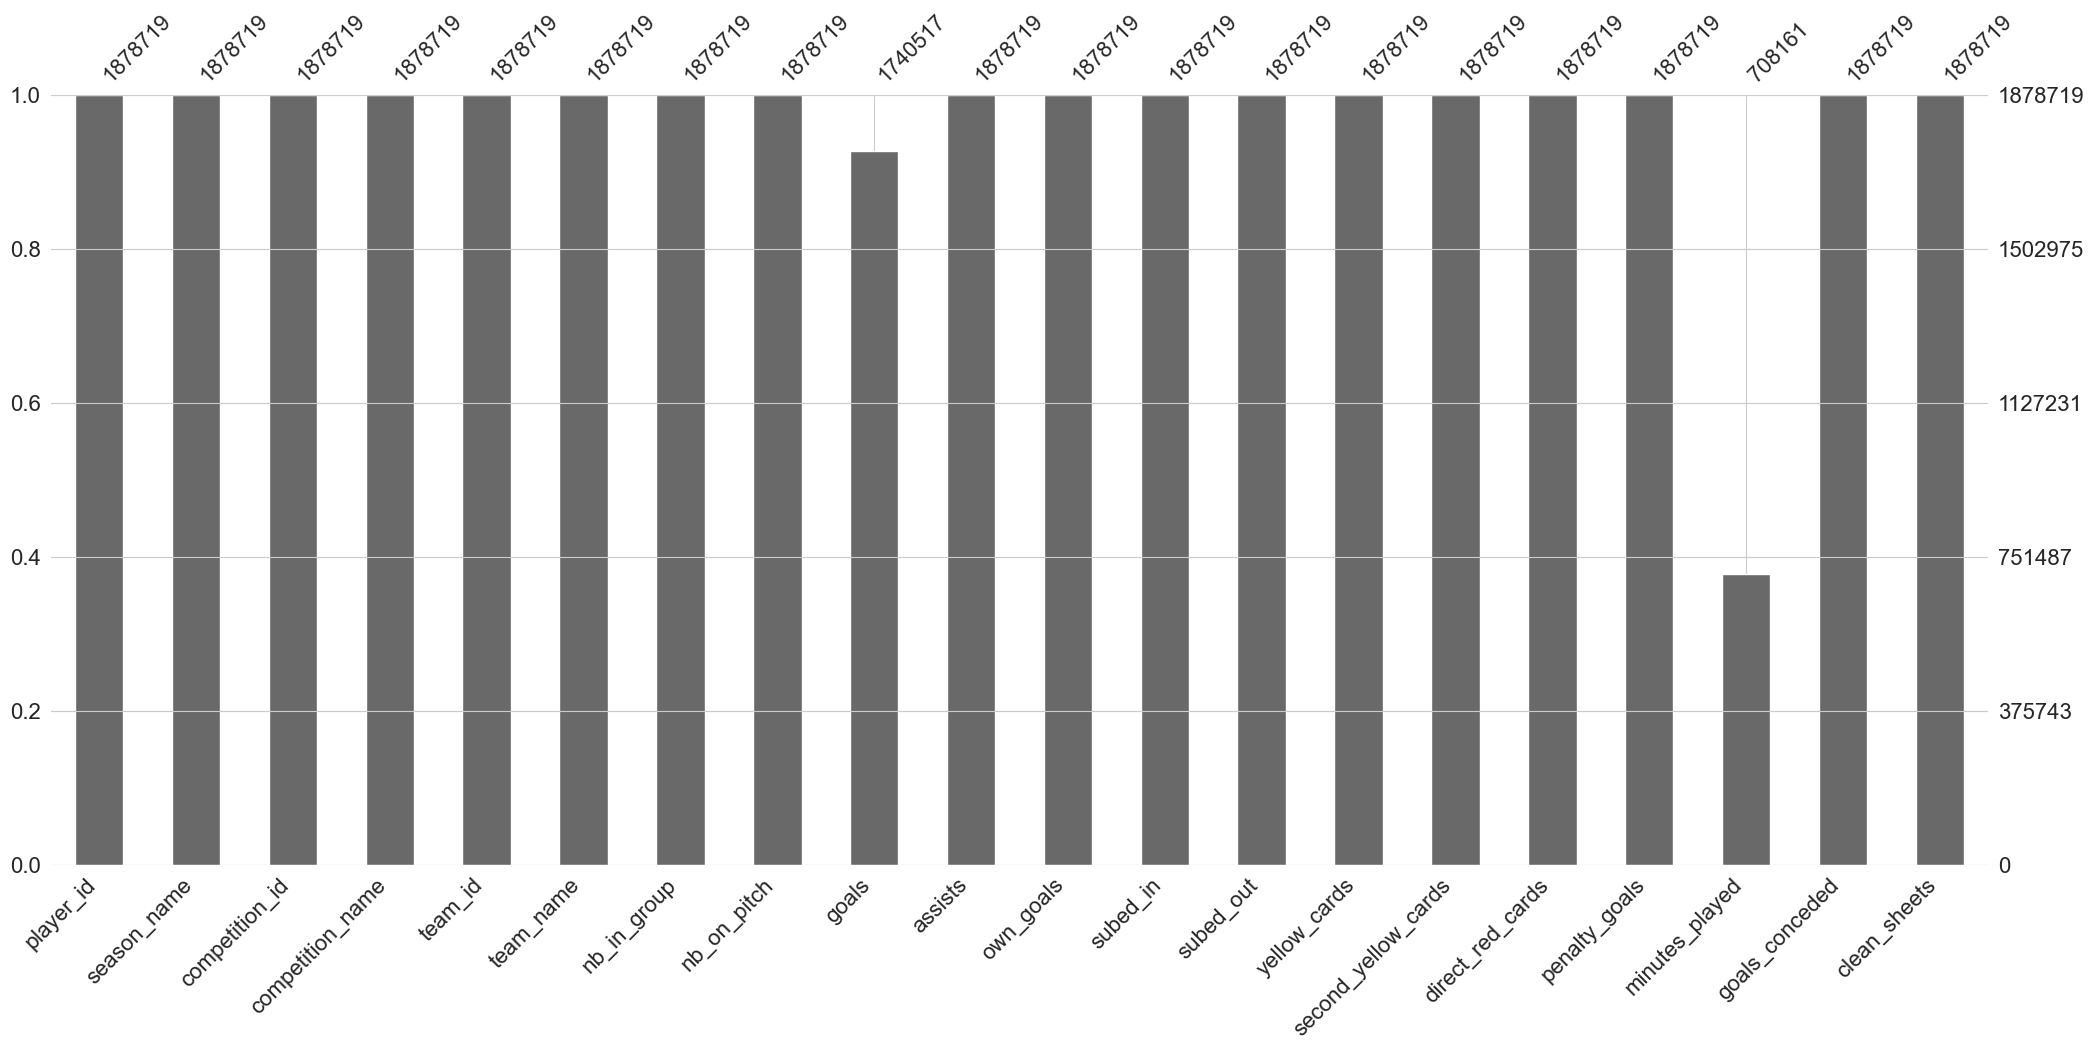

In [13]:
#missing value bar visualization
msno.bar(df)
plt.show()

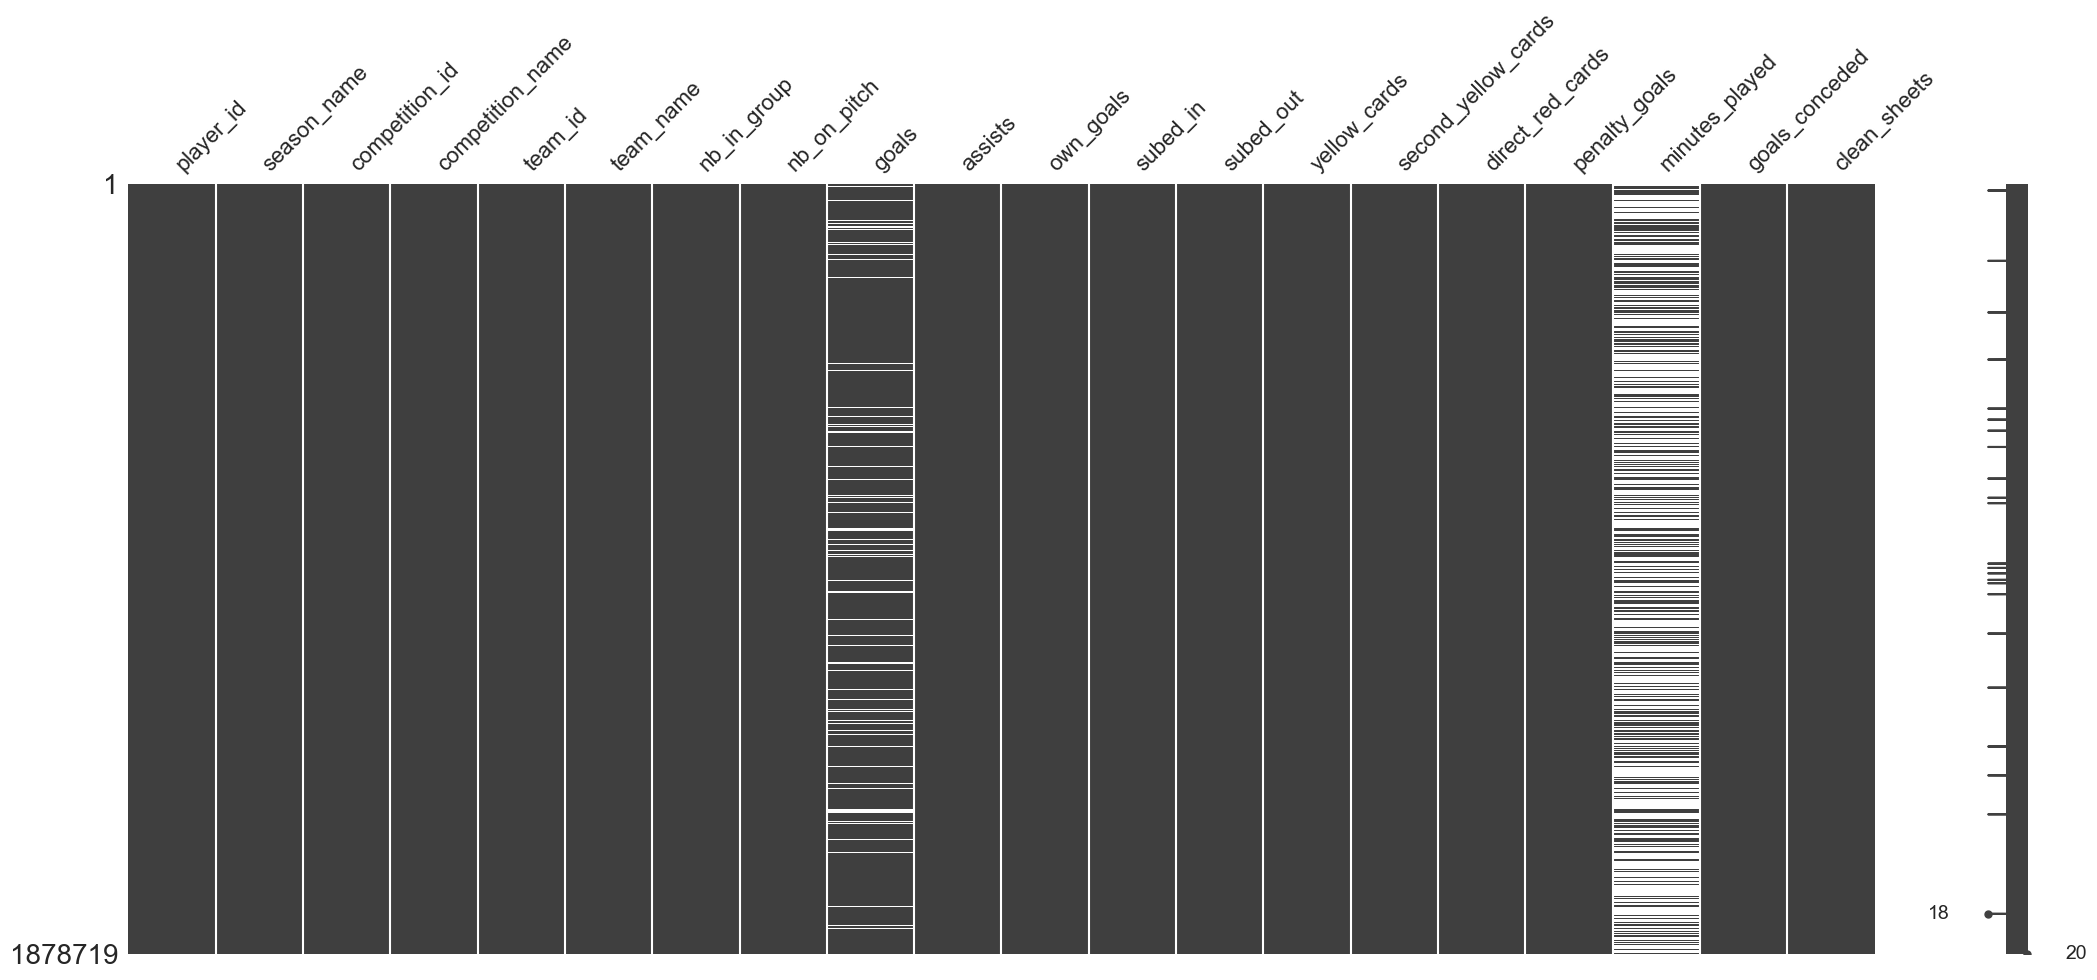

In [14]:

# missing value visualization
msno.matrix(df)
plt.show()

In [15]:
# Missing Value percentage

missing_value = df.isna().sum()
missing_value_percentage = 100*missing_value/len(df)
missing_value_percentage = missing_value_percentage.round(2).sort_values(ascending=False)
missing_value_percentage = missing_value_percentage[missing_value_percentage.values>0]
missing_value_percentage.reset_index()

,index,0
0,minutes_played,62.31
1,goals,7.36


In [16]:
# data Frame of missing value
missing_df = pd.DataFrame(
    {
        "Missing_Count" : missing_value,
        "Percentage" : missing_value_percentage
    }
)
missing_df = missing_df[missing_df['Missing_Count']>0].sort_values(by = "Missing_Count",ascending=False)
missing_df

,Missing_Count,Percentage
minutes_played,1170558,62.31
goals,138202,7.36


> ## Duplicate Value Analysis
      

`No Duplicate value`

In [17]:

# counting duplpicate value
df.duplicated().sum()

np.int64(0)

In [18]:
df.sample(10)

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
1331676,562049,24/25,IT1,Serie A,430,ACF Fiorentina,12,12,1.0,3,0,1,6,3,0,0,0,857.0,0,0
1622144,740230,21/22,P23C,Revelação U23 - Championship,67731,Portimonense SAD U23,6,6,1.0,0,0,2,3,1,0,0,0,332.0,0,0
202446,13604,17/18,GBFL,EFL Trophy,3884,AFC Wimbledon,3,3,0.0,0,0,0,0,0,0,0,0,NaN,0,0
1710082,817468,20/21,IT3P,Playoff Serie C,1429,Cesena FC,1,0,0.0,0,0,0,0,0,0,0,0,NaN,0,0
849030,345468,23/24,ESJP,Jupiler Pro League playoff Europa League,1184,KRC Genk,1,1,0.0,0,0,0,1,0,0,0,0,NaN,0,0
211737,138267,2023,KAZP,Kazakhstan Cup,34239,Kaspiy Aktau,1,1,0.0,0,0,0,1,0,0,0,0,NaN,0,0
1484681,644799,2019,MLSP,US Open Cup,54716,Reno 1868 FC,1,1,0.0,0,0,0,0,0,0,0,0,NaN,0,0
1345704,56821,09/10,EJPL,JPL Play-Offs I,3508,Zulte Waregem,8,4,1.0,0,0,1,1,0,0,0,0,244.0,0,0
1727772,832216,2020,CS,Copa Sudamericana,2734,FBC Melgar,1,0,0.0,0,0,0,0,0,0,0,0,NaN,0,0
777314,3217,00/01,GB1,Premier League,31,Liverpool FC,27,27,2.0,9,0,11,8,2,0,0,0,754.0,0,0


### Solving Issue

In [19]:
# Dropping columns
df.drop(columns=[  'competition_id', 
       'team_id'] , inplace=True)

In [20]:
#  null values
df.isna().sum()

player_id                    0
season_name                  0
competition_name             0
team_name                    0
nb_in_group                  0
nb_on_pitch                  0
goals                   138202
assists                      0
own_goals                    0
subed_in                     0
subed_out                    0
yellow_cards                 0
second_yellow_cards          0
direct_red_cards             0
penalty_goals                0
minutes_played         1170558
goals_conceded               0
clean_sheets                 0
dtype: int64

In [21]:
# filling null value
df['goals'].fillna(df['goals'].median() , inplace=True)
df['minutes_played'].fillna(df['minutes_played'].median() , inplace=True)

C:\Users\PL\AppData\Local\Temp\ipykernel_5196\714657797.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['goals'].fillna(df['goals'].median() , inplace=True)
C:\Users\PL\AppData\Local\Temp\ipykernel_5196\714657797.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [22]:
df.isna().sum()

player_id              0
season_name            0
competition_name       0
team_name              0
nb_in_group            0
nb_on_pitch            0
goals                  0
assists                0
own_goals              0
subed_in               0
subed_out              0
yellow_cards           0
second_yellow_cards    0
direct_red_cards       0
penalty_goals          0
minutes_played         0
goals_conceded         0
clean_sheets           0
dtype: int64

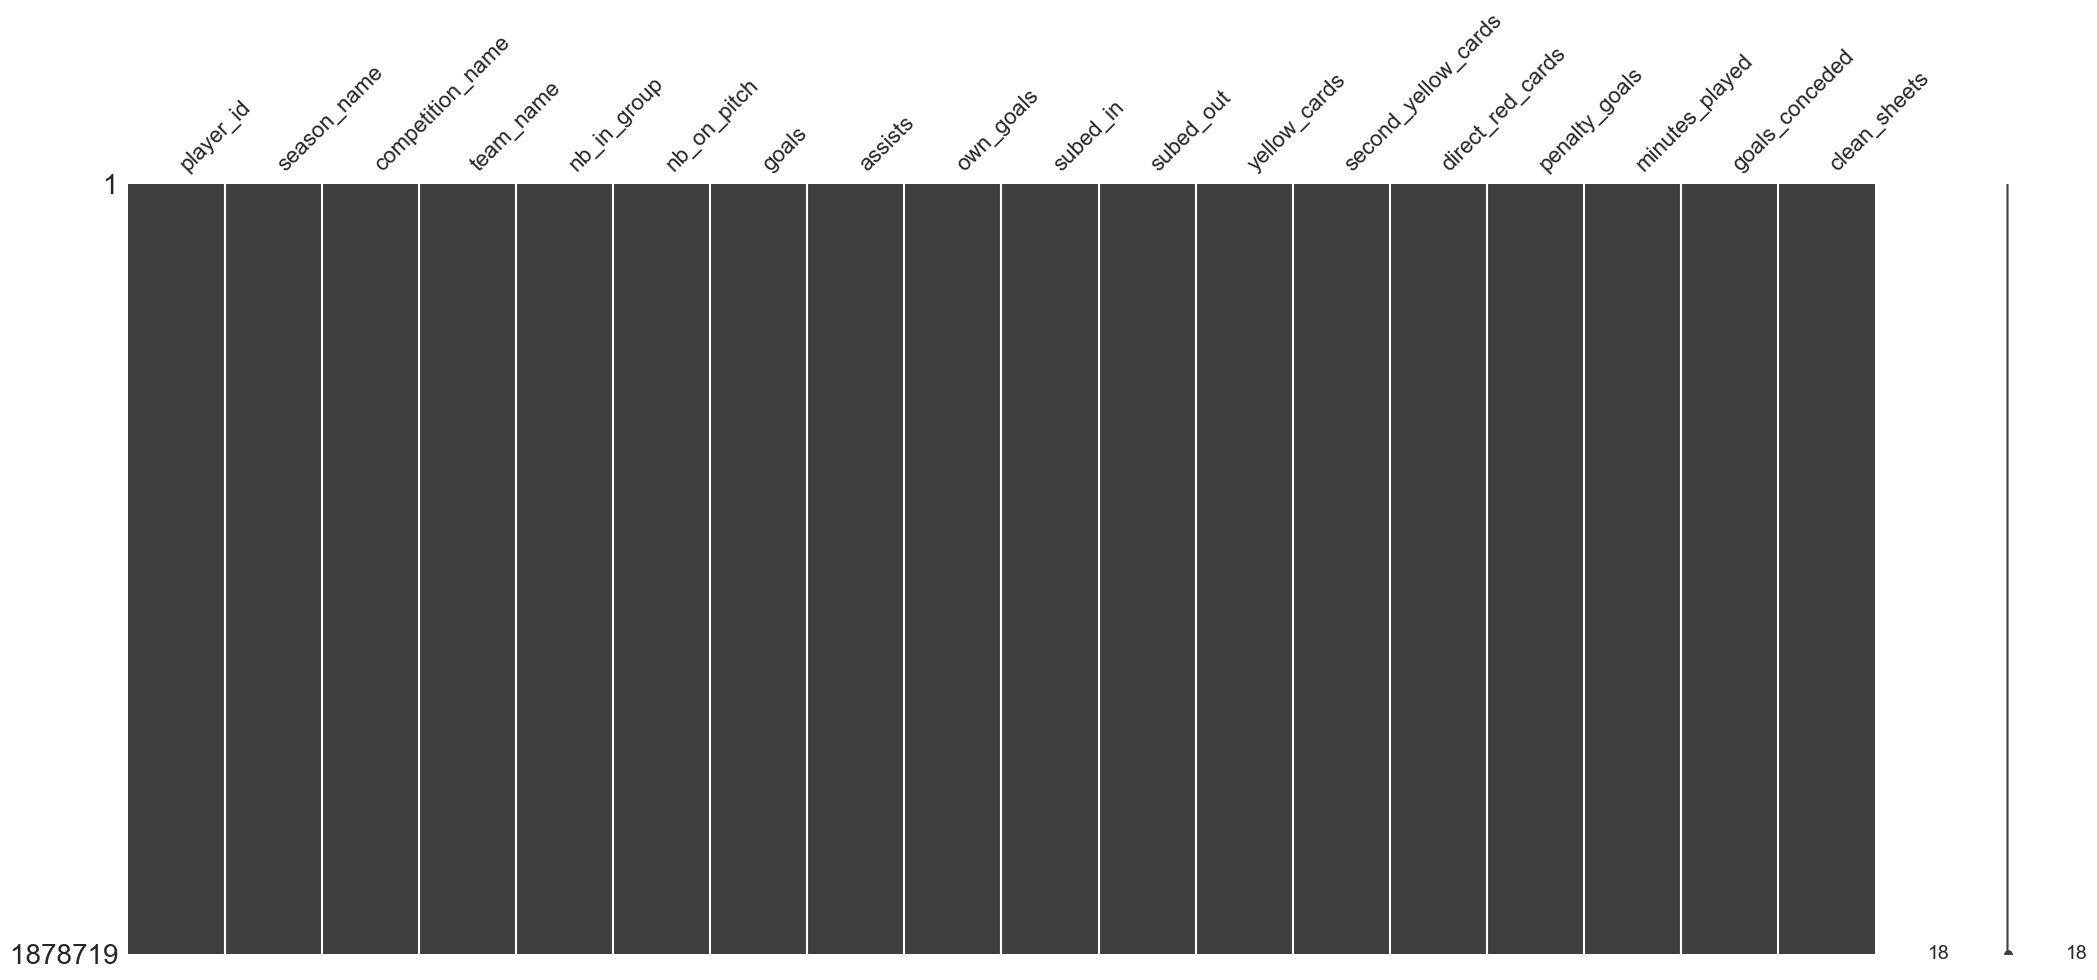

In [23]:
#missing matrix
msno.matrix(df)
plt.show()

> ## Univariate Analysis

#### **Numerical Analysis**
    
  - *Columns that will be analyze*
      - **Goals**
      - **Assists**
      - **Own Goals**
      - **Subbed In**
      - **Subbed out**
      - **Yellow Cards**
      - **Second Yellow Cards**
      - **Dired Red Cards**
      - **Penalty Goals**
      - **Minutes played**
      - **Goals Conceded**
      - **Clean Sheets**

In [24]:
df.columns.to_list()

['player_id',
 'season_name',
 'competition_name',
 'team_name',
 'nb_in_group',
 'nb_on_pitch',
 'goals',
 'assists',
 'own_goals',
 'subed_in',
 'subed_out',
 'yellow_cards',
 'second_yellow_cards',
 'direct_red_cards',
 'penalty_goals',
 'minutes_played',
 'goals_conceded',
 'clean_sheets']

> ### **Goals**

**Statistical Summary**
 1. Max  : **50.0**
 2. Minimum  : **0.0**
 3. Mean  : **0.88**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **4.89**
 7. Standard  : **2.21**
 8. Skewness  : **4.74**
 9. Kurtosis  : **32.39**
 10. Outliers Identified: **197,491**

**Interpretation of Visualization and Insights**

In [25]:
df['goals'].sample(5)

1749062    1.0
150145     0.0
1093349    0.0
305385     0.0
1150569    0.0
Name: goals, dtype: float64

__________goals__________

Statistical Summary
count    1.878719e+06
mean     8.826355e-01
std      2.212348e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      5.000000e+01
Name: goals, dtype: float64
__________goals__________

Statistical Summary
 Max  : 50.0
 Minimum  : 0.0
 Mean  : 0.88
 Median  : 0.0
 Mode  : 0.0
 Variance : 4.89
 Standard  : 2.21
 Skewness  : 4.74
 Kurtosis  : 32.39

 Outlier Detection (IQR Method)
  Outliers Identified: 197,491


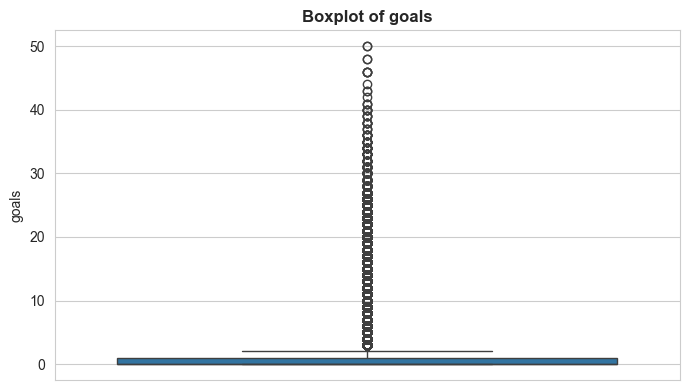

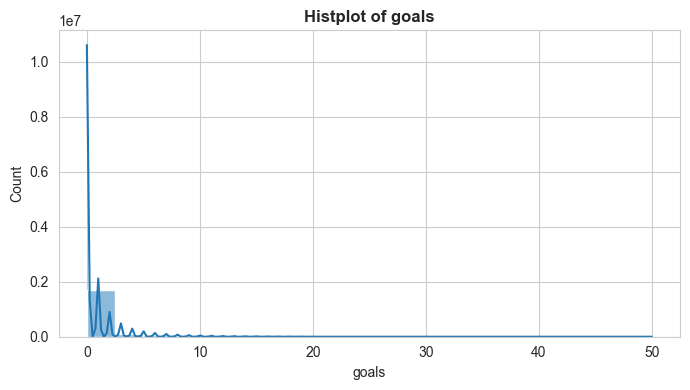

In [26]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'goals')
    

> ### **Assists**

**Statistical Summary**
 1. Max  : **29.0**
 2. Minimum  : **0.0**
 3. Mean  : **0.45**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **1.56**
 7. Standard  : **1.25**
 8. Skewness  : **4.74**
 9. Kurtosis  : **32.45**
 10. Outliers Identified: **381,630**

**Interpretation of Visualization and Insights**

In [27]:
df['assists'].head(3)

0    0
1    0
2    0
Name: assists, dtype: int64

__________assists__________

Statistical Summary
count    1.878719e+06
mean     4.469455e-01
std      1.247370e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.900000e+01
Name: assists, dtype: float64
__________assists__________

Statistical Summary
 Max  : 29
 Minimum  : 0
 Mean  : 0.45
 Median  : 0.0
 Mode  : 0
 Variance : 1.56
 Standard  : 1.25
 Skewness  : 4.74
 Kurtosis  : 32.45

 Outlier Detection (IQR Method)
  Outliers Identified: 381,630


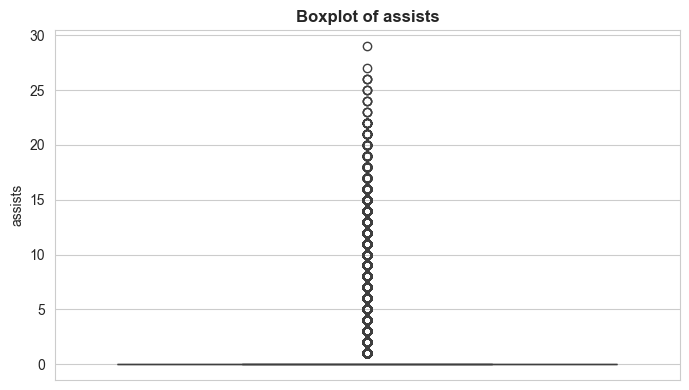

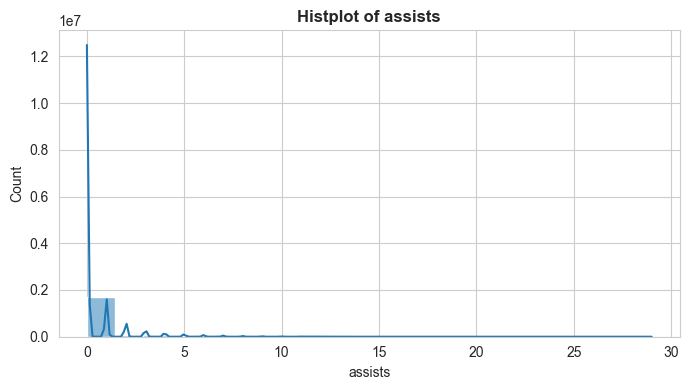

In [28]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'assists')
    

 > ### **Own Goals**

**Statistical Summary**
 1. Max  : **9.0**
 2. Minimum  : **0.0**
 3. Mean  : **0.02**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **0.02**
 7. Standard  : **0.13**
 8. Skewness  : **9.59**
 9. Kurtosis  : **123.05**
 10. Outliers Identified: **27,305**

**Interpretation of Visualization and Insights**

In [29]:
df['own_goals'].sample(5)

1760087    0
1587276    0
1610111    0
82356      0
1262086    0
Name: own_goals, dtype: int64

__________own_goals__________

Statistical Summary
count    1.878719e+06
mean     1.532853e-02
std      1.300537e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.000000e+00
Name: own_goals, dtype: float64
__________own_goals__________

Statistical Summary
 Max  : 9
 Minimum  : 0
 Mean  : 0.02
 Median  : 0.0
 Mode  : 0
 Variance : 0.02
 Standard  : 0.13
 Skewness  : 9.59
 Kurtosis  : 123.05

 Outlier Detection (IQR Method)
  Outliers Identified: 27,305


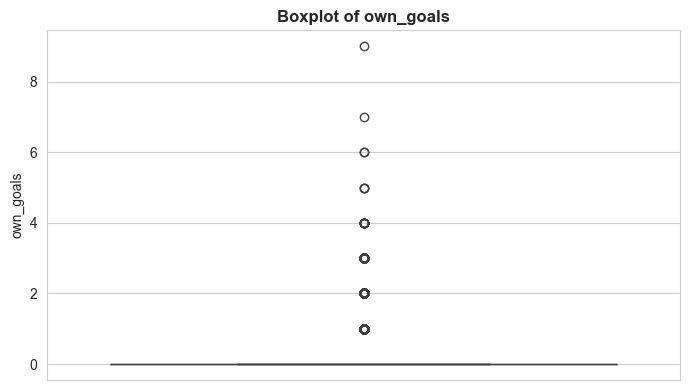

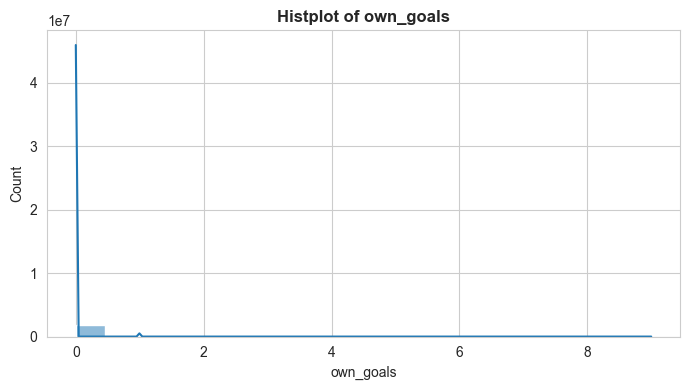

In [30]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

#  Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df ,'own_goals')
    

> ### **Subbed In**

**Statistical Summary**
 1. Max  : **38.0**
 2. Minimum  : **0.0**
 3. Mean  : **1.67**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **9.21**
 7. Standard  : **3.04**
 8. Skewness  : **2.9**
 9. Kurtosis  : **10.48**
 10. Outliers Identified: ** 179,587**

**Interpretation of Visualization and Insights**

In [31]:
df['subed_in'].sample(3)

1777759     2
1523989    20
513695      0
Name: subed_in, dtype: int64

__________subed_in__________

Statistical Summary
count    1.878719e+06
mean     1.673163e+00
std      3.035122e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      3.800000e+01
Name: subed_in, dtype: float64
__________subed_in__________

Statistical Summary
 Max  : 38
 Minimum  : 0
 Mean  : 1.67
 Median  : 0.0
 Mode  : 0
 Variance : 9.21
 Standard  : 3.04
 Skewness  : 2.9
 Kurtosis  : 10.48

 Outlier Detection (IQR Method)
  Outliers Identified: 179,587


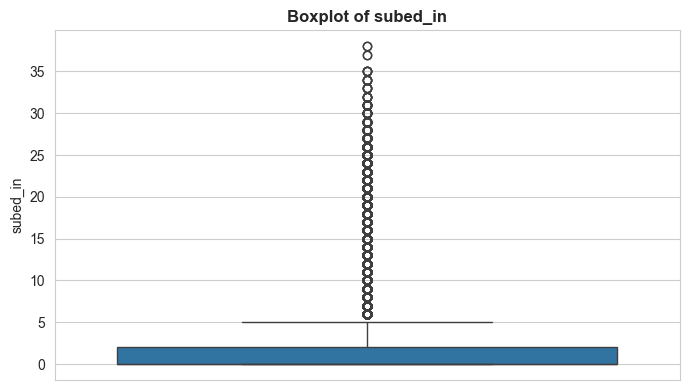

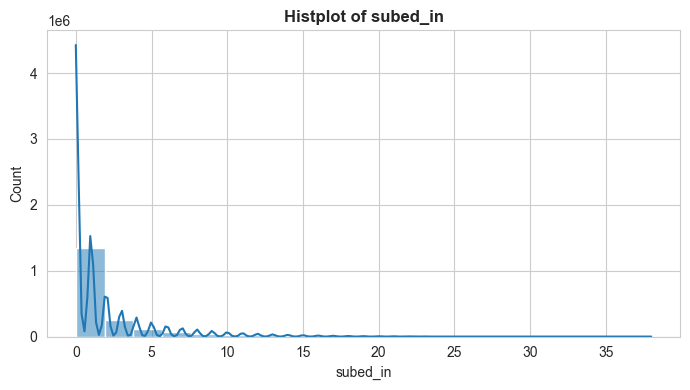

In [32]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

#  Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'subed_in')
    

> ###  **Subbed out**

**Statistical Summary**
 1. Max  : **40.0**
 2. Minimum  : **0.0**
 3. Mean  : **1.86**|
 4. Median  : **1.0**
 5. Mode  : **0.0**
 6. Variance : **10.63**
 7. Standard  : **3.26**
 8. Skewness  : **2.78**
 9. Kurtosis  : **9.42**
 10. Outliers Identified: **203,122**

**Interpretation of Visualization and Insights**

In [33]:
df['subed_out'].head(5)

0    2
1    8
2    0
3    0
4    1
Name: subed_out, dtype: int64

__________subed_out__________

Statistical Summary
count    1.878719e+06
mean     1.855993e+00
std      3.260543e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      4.000000e+01
Name: subed_out, dtype: float64
__________subed_out__________

Statistical Summary
 Max  : 40
 Minimum  : 0
 Mean  : 1.86
 Median  : 1.0
 Mode  : 0
 Variance : 10.63
 Standard  : 3.26
 Skewness  : 2.78
 Kurtosis  : 9.42

 Outlier Detection (IQR Method)
  Outliers Identified: 203,122


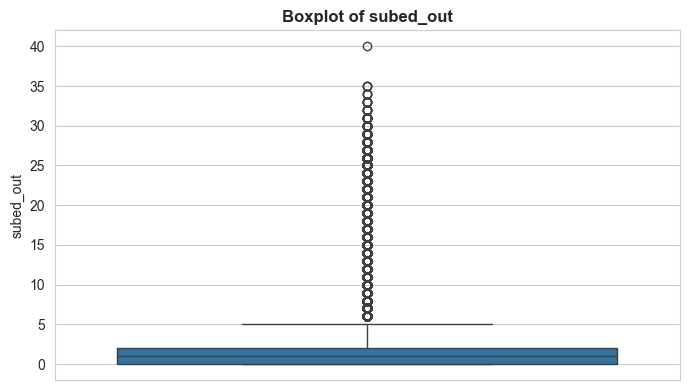

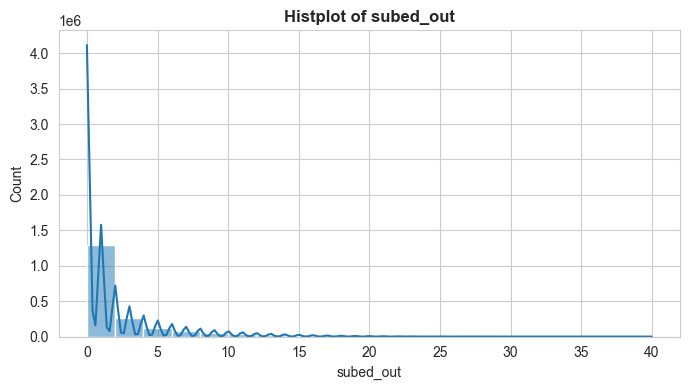

In [34]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'subed_out')
    

> ### **Yellow Cards**

**Statistical Summary**
 1. Max  : **21.0**
 2. Minimum  : **0.0**
 3. Mean  : **1.11**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **3.69**
 7. Standard  : **1.92**
 8. Skewness  : **2.47**
 9. Kurtosis  : **7.3**
 10. Outliers Identified: **296,434**

**Interpretation of Visualization and Insights**

In [35]:
df['yellow_cards'].head(5)

0    0
1    1
2    0
3    0
4    1
Name: yellow_cards, dtype: int64

__________yellow_cards__________

Statistical Summary
count    1.878719e+06
mean     1.111522e+00
std      1.919704e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      2.100000e+01
Name: yellow_cards, dtype: float64
__________yellow_cards__________

Statistical Summary
 Max  : 21
 Minimum  : 0
 Mean  : 1.11
 Median  : 0.0
 Mode  : 0
 Variance : 3.69
 Standard  : 1.92
 Skewness  : 2.47
 Kurtosis  : 7.3

 Outlier Detection (IQR Method)
  Outliers Identified: 296,434


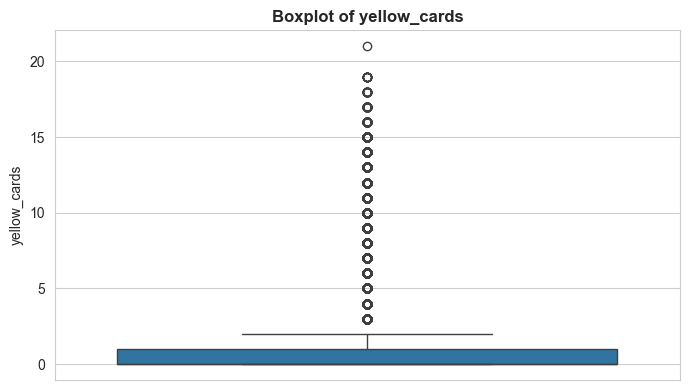

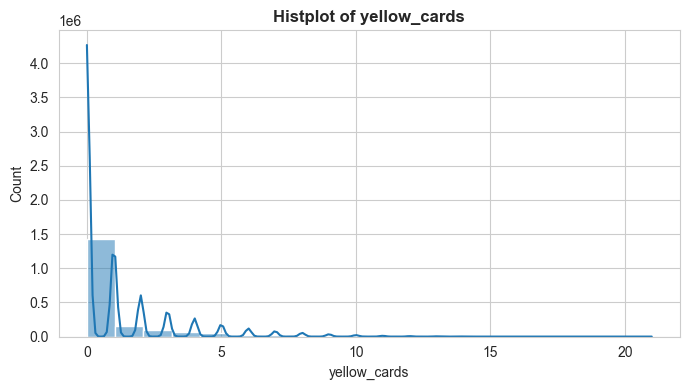

In [36]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'yellow_cards')
    

> ###  **Second Yellow Cards**

**Statistical Summary**
 1. Max  : **5.0**
 2. Minimum  : **0.0**
 3. Mean  : **0.3**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **0.04**
 7. Standard  : **0.19**
 8. Skewness  : **6.19**
 9. Kurtosis  : **44.17**
 10. Outliers Identified: **59,840**

**Interpretation of Visualization and Insights**

In [37]:
df['second_yellow_cards'].head(3)

0    0
1    0
2    0
Name: second_yellow_cards, dtype: int64

__________second_yellow_cards__________

Statistical Summary
count    1.878719e+06
mean     3.394068e-02
std      1.930695e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e+00
Name: second_yellow_cards, dtype: float64
__________second_yellow_cards__________

Statistical Summary
 Max  : 5
 Minimum  : 0
 Mean  : 0.03
 Median  : 0.0
 Mode  : 0
 Variance : 0.04
 Standard  : 0.19
 Skewness  : 6.19
 Kurtosis  : 44.17

 Outlier Detection (IQR Method)
  Outliers Identified: 59,840


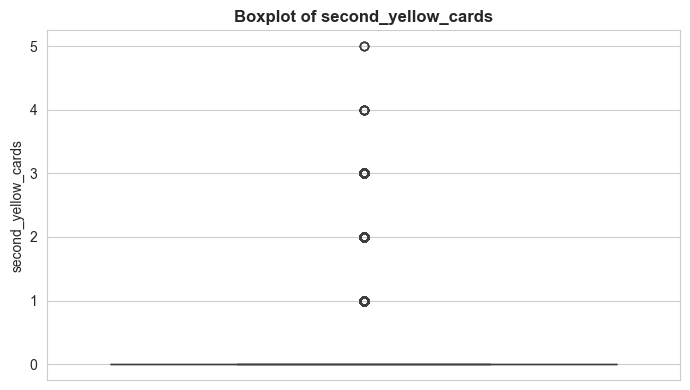

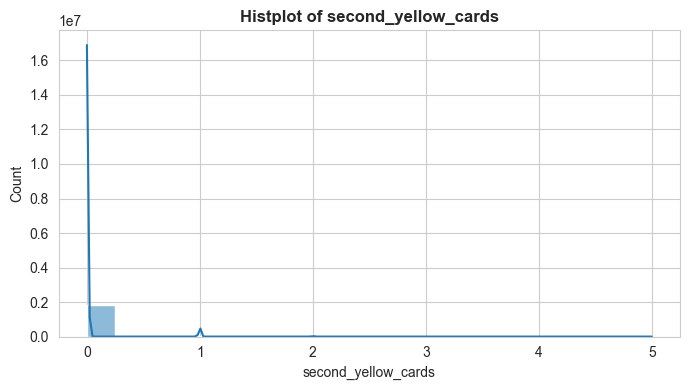

In [38]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'second_yellow_cards')
    

> ### **Direct Red Cards**

**Statistical Summary**
 1. Max  : **4.0**
 2. Minimum  : **0.0**
 3. Mean  : **0.04**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **0.04**
 7. Standard  : **0.19**
 8. Skewness  : **5.93**
 9. Kurtosis  : **39.3**
 10. Outliers Identified: **62,514**

**Interpretation of Visualization and Insights**

In [39]:
df['direct_red_cards'].head(3)

0    1
1    0
2    0
Name: direct_red_cards, dtype: int64

__________direct_red_cards__________

Statistical Summary
count    1.878719e+06
mean     3.513724e-02
std      1.945535e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.000000e+00
Name: direct_red_cards, dtype: float64
__________direct_red_cards__________

Statistical Summary
 Max  : 4
 Minimum  : 0
 Mean  : 0.04
 Median  : 0.0
 Mode  : 0
 Variance : 0.04
 Standard  : 0.19
 Skewness  : 5.93
 Kurtosis  : 39.3

 Outlier Detection (IQR Method)
  Outliers Identified: 62,514


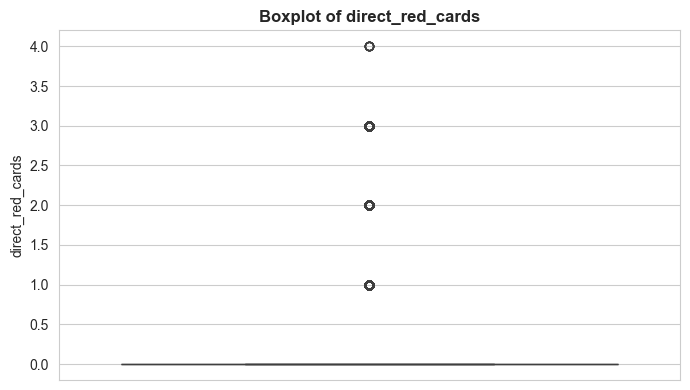

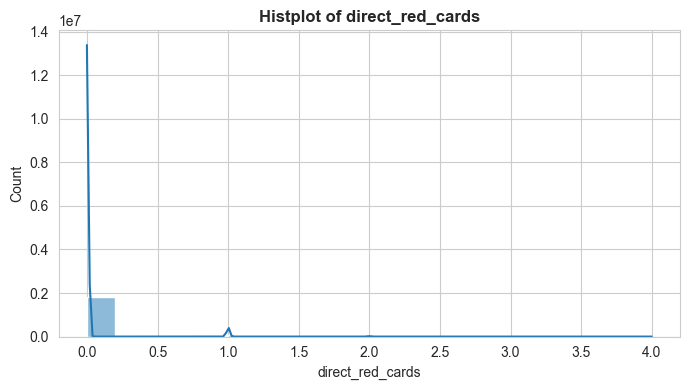

In [40]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'direct_red_cards')
    

> ### **Penalty Goals**

**Statistical Summary**
 1. Max  : **14.0**
 2. Minimum  : **0.0**
 3. Mean  : **0.08**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **0.19**
 7. Standard  : **0.44**
 8. Skewness  : **8.9**
 9. Kurtosis  : **106.81**
 10. Outliers Identified: **82,308**

**Interpretation of Visualization and Insights**

In [41]:
df['penalty_goals'].head(4)

0    0
1    0
2    0
3    0
Name: penalty_goals, dtype: int64

__________penalty_goals__________

Statistical Summary
count    1.878719e+06
mean     7.551528e-02
std      4.414087e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.400000e+01
Name: penalty_goals, dtype: float64
__________penalty_goals__________

Statistical Summary
 Max  : 14
 Minimum  : 0
 Mean  : 0.08
 Median  : 0.0
 Mode  : 0
 Variance : 0.19
 Standard  : 0.44
 Skewness  : 8.9
 Kurtosis  : 106.81

 Outlier Detection (IQR Method)
  Outliers Identified: 82,308


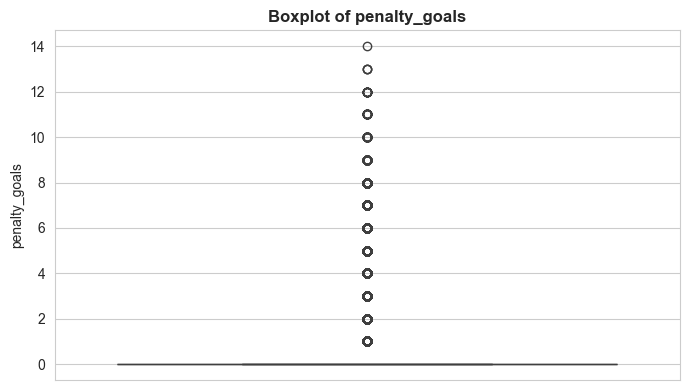

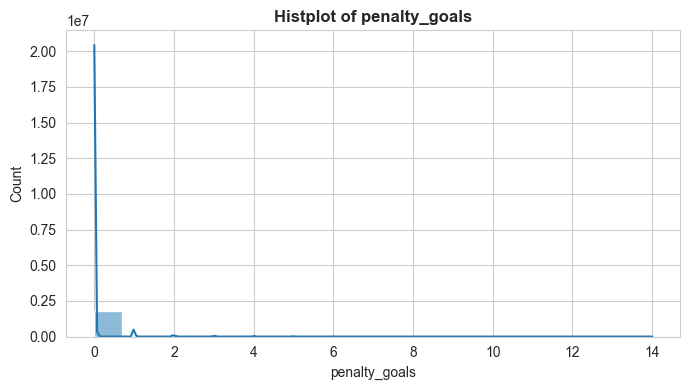

In [42]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'penalty_goals')
    

> ### **Minutes played**

**Statistical Summary**
 1. Max  : **4590.0**
 2. Minimum  : **438.46**
 3. Mean  : **438.46**|
 4. Median  : **337.0**
 5. Mode  : **337.0**
 6. Variance : **192130.13**
 7. Standard  : **438.33**
 8. Skewness  : **3.94**
 9. Kurtosis  : **17.81**
 10. Outliers Identified: **707,558**

**Interpretation of Visualization and Insights**

In [43]:
df['minutes_played']

0           337.0
1          1580.0
2           337.0
3           337.0
4           388.0
            ...  
1878714     337.0
1878715     337.0
1878716     337.0
1878717     337.0
1878718     337.0
Name: minutes_played, Length: 1878719, dtype: float64

__________minutes_played__________

Statistical Summary
count    1.878719e+06
mean     4.384647e+02
std      4.383265e+02
min      1.000000e+00
25%      3.370000e+02
50%      3.370000e+02
75%      3.370000e+02
max      4.590000e+03
Name: minutes_played, dtype: float64
__________minutes_played__________

Statistical Summary
 Max  : 4590.0
 Minimum  : 1.0
 Mean  : 438.46
 Median  : 337.0
 Mode  : 337.0
 Variance : 192130.13
 Standard  : 438.33
 Skewness  : 3.94
 Kurtosis  : 17.81

 Outlier Detection (IQR Method)
  Outliers Identified: 707,558


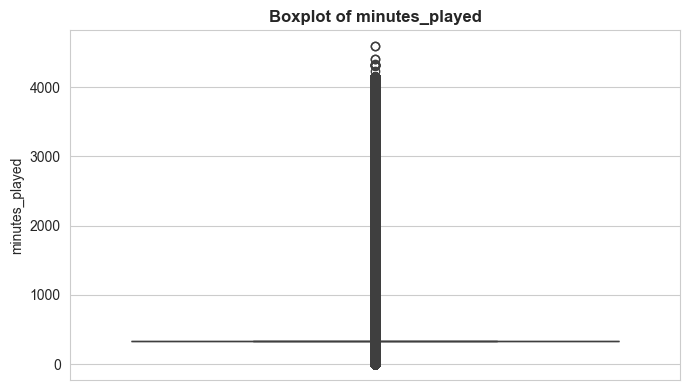

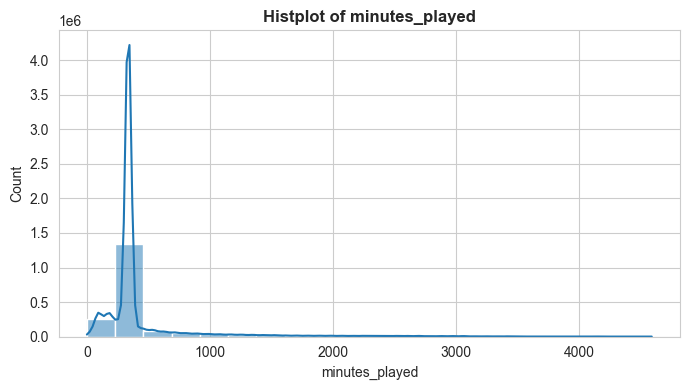

In [44]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'minutes_played')
    

> ###  **Goals Conceded**

**Statistical Summary**
 1. Max  : **111.0**
 2. Minimum  : **-1**
 3. Mean  : **0.08**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **21.22**
 7. Standard  : **4.61**
 8. Skewness  : **7.94**
 9. Kurtosis  : **73.19**
 10. Outliers Identified: **127,471**

**Interpretation of Visualization and Insights**

In [45]:
df['goals_conceded'].head(3)

0    0
1    0
2    0
Name: goals_conceded, dtype: int64

__________goals_conceded__________

Statistical Summary
count    1.878719e+06
mean     8.014999e-01
std      4.606050e+00
min     -1.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.110000e+02
Name: goals_conceded, dtype: float64
__________goals_conceded__________

Statistical Summary
 Max  : 111
 Minimum  : -1
 Mean  : 0.8
 Median  : 0.0
 Mode  : 0
 Variance : 21.22
 Standard  : 4.61
 Skewness  : 7.94
 Kurtosis  : 73.19

 Outlier Detection (IQR Method)
  Outliers Identified: 127,471


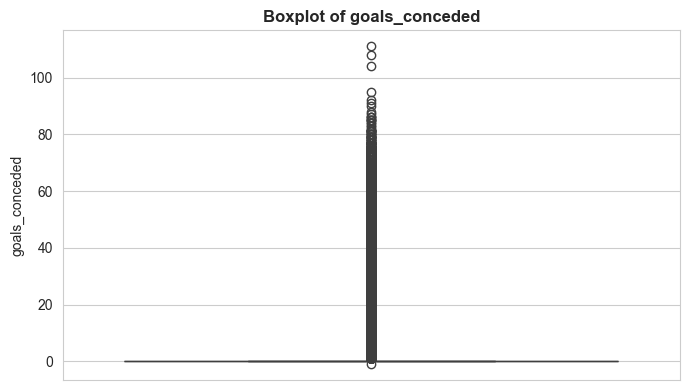

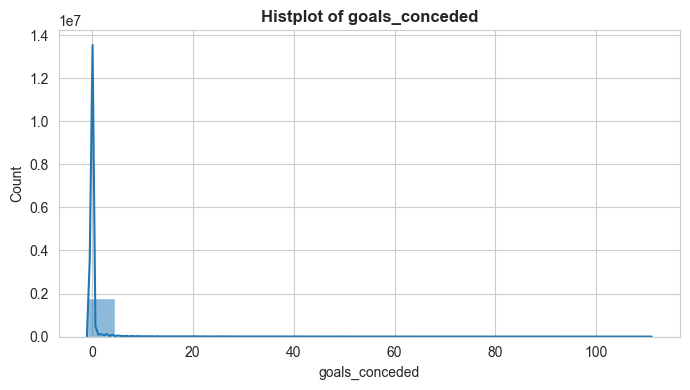

In [46]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'goals_conceded')
    

> ### **Clean Sheets**

**Statistical Summary**
 1. Max  : **29.0**
 2. Minimum  : **0.0**
 3. Mean  : **0.19**|
 4. Median  : **0.0**
 5. Mode  : **0.0**
 6. Variance : **1.45**
 7. Standard  : **1.2**
 8. Skewness  : **8.89**
 9. Kurtosis  : **93.79**
 10. Outliers Identified: **90,195**

**Interpretation of Visualization and Insights**

In [47]:
df['clean_sheets'].head(3)

0    0
1    0
2    0
Name: clean_sheets, dtype: int64

__________clean_sheets__________

Statistical Summary
count    1.878719e+06
mean     1.911073e-01
std      1.204661e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.900000e+01
Name: clean_sheets, dtype: float64
__________clean_sheets__________

Statistical Summary
 Max  : 29
 Minimum  : 0
 Mean  : 0.19
 Median  : 0.0
 Mode  : 0
 Variance : 1.45
 Standard  : 1.2
 Skewness  : 8.89
 Kurtosis  : 93.79

 Outlier Detection (IQR Method)
  Outliers Identified: 90,195


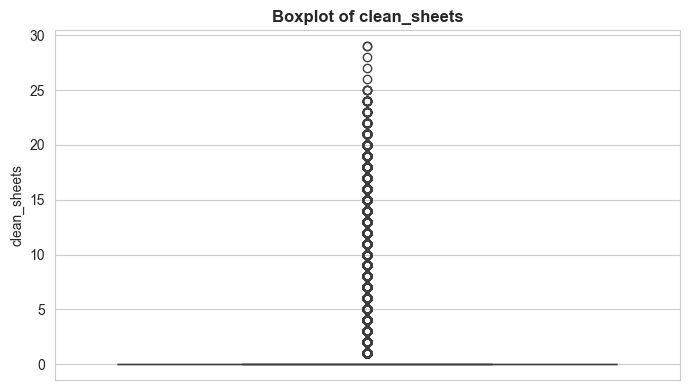

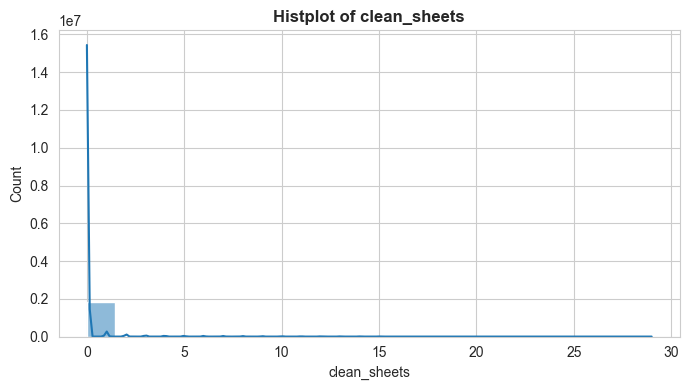

In [48]:
# Function for Numerical Column analysis

def analyze_numerical(df , col):
    
    '''
    This function takes the dataset and a neumerical columns as an input and
    gives a statistical summary of that columns including boxplot , histrogram ,
    kde plot most important it checks the outlier using IQR method
    '''
    
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(df[col].describe())
    
    
    #Descriptive statistics
    print(f"__________{col}__________")
    print("\nStatistical Summary")
    print(f" Max  : {df[col].max().round(2)}")
    print(f" Minimum  : {df[col].min().round(2)}")
    print(f" Mean  : {df[col].mean().round(2)}")
    print(f" Median  : {df[col].median().round(2)}")
    print(f" Mode  : {df[col].mode().iloc[0]}")
    print(f" Variance : {df[col].var().round(2)}")
    print(f" Standard  : {df[col].std().round(2)}")
    print(f" Skewness  : {df[col].skew().round(2)}")
    print(f" Kurtosis  : {df[col].kurtosis().round(2)}")
    
    

# 🔍 Outlier Detection Using IQR Method
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n Outlier Detection (IQR Method)")
    print(f"  Outliers Identified: {len(outlier):,}")
    
       
    # Creating visualization
    plt.figure(figsize=(7,4))
    # boxplot
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}", weight='bold', fontsize=12) 
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
    plt.figure(figsize=(7,4))
    # histplot
    sns.histplot(df[col] , bins=20 , kde=True)
    plt.title(f"Histplot of {col}", weight='bold', fontsize=12) 
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
        
    

analyze_numerical(df , 'clean_sheets')
    

> # **`Now We will Only Work with these row that have more goal than 0`**

- Row **570,066**
- Col **20**

In [49]:
df = df[df['goals']>0]


In [89]:
# droping clean sheet column . No value more than greater than 0
df.drop(columns= 'clean_sheets'
 , inplace=True)

In [50]:
df.shape

(570066, 18)

## Bivariate Analysis

In [51]:
df.columns.to_list()

['player_id',
 'season_name',
 'competition_name',
 'team_name',
 'nb_in_group',
 'nb_on_pitch',
 'goals',
 'assists',
 'own_goals',
 'subed_in',
 'subed_out',
 'yellow_cards',
 'second_yellow_cards',
 'direct_red_cards',
 'penalty_goals',
 'minutes_played',
 'goals_conceded',
 'clean_sheets']

In [52]:
df = df[df['goals']>0]


In [53]:
df.shape

(570066, 18)

#### **`Numerical Vs Numerical`**

> ### **Goal Vs Assists**

In [54]:
df['goals'].shape

(570066,)

**NO Correlation**

The Correlation   : 0.38


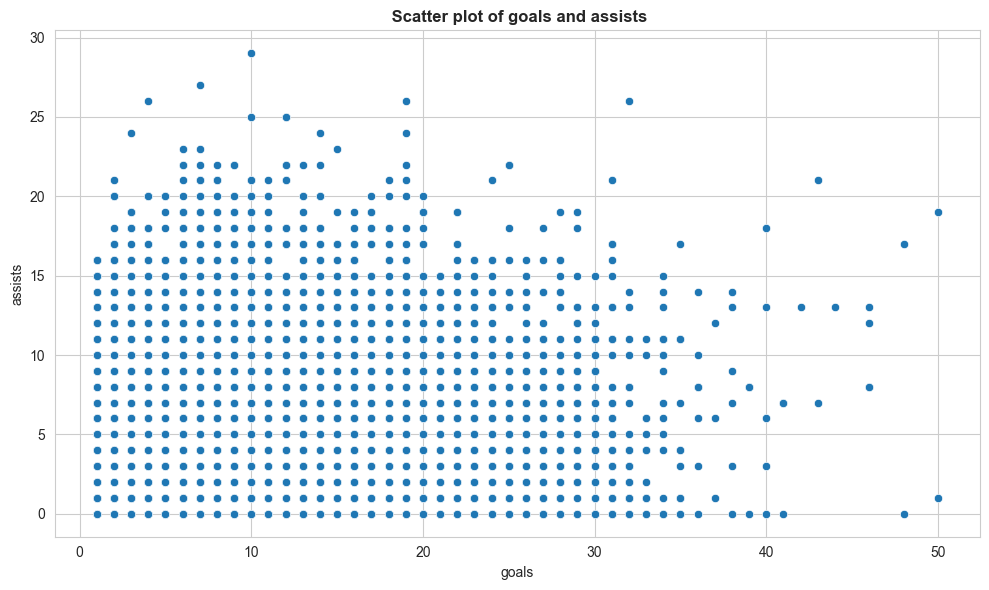

In [55]:
def numerical_pair(df , col1 , col2 ):
    
    
    '''
    This function Takes 2  numerical col as input and compare them using correlation matrix.It will also construct scatter plot , regression plot
    '''
    
    corr = df[col1].corr(df[col2])
    print( f"The Correlation   : {corr:.2f}")
    
    plt.figure(figsize=(10,6))
    #scatter plot
    sns.scatterplot(data = df , x=df[col1] , y = df[col2])
    plt.title(f" Scatter plot of {col1} and {col2}" , weight='bold')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.tight_layout()
    plt.show()
    
        
    # plt.figure(figsize=(10,6))
    # #Regression plot
    # sns.regplot(data = df , x=df[col1] , y = df[col2])
    # plt.title(f" Scatter plot of {col1} and {col2}" , weight='bold')
    # plt.xlabel(col1)
    # plt.ylabel(col2)
    # plt.tight_layout()
    # plt.show()
        
    # # plt.figure(figsize=(10,6))
    

numerical_pair(df , 'goals' , 'assists')
    
    

> ### **Subbed In Vs Subbed Out**

The Correlation   : 0.36


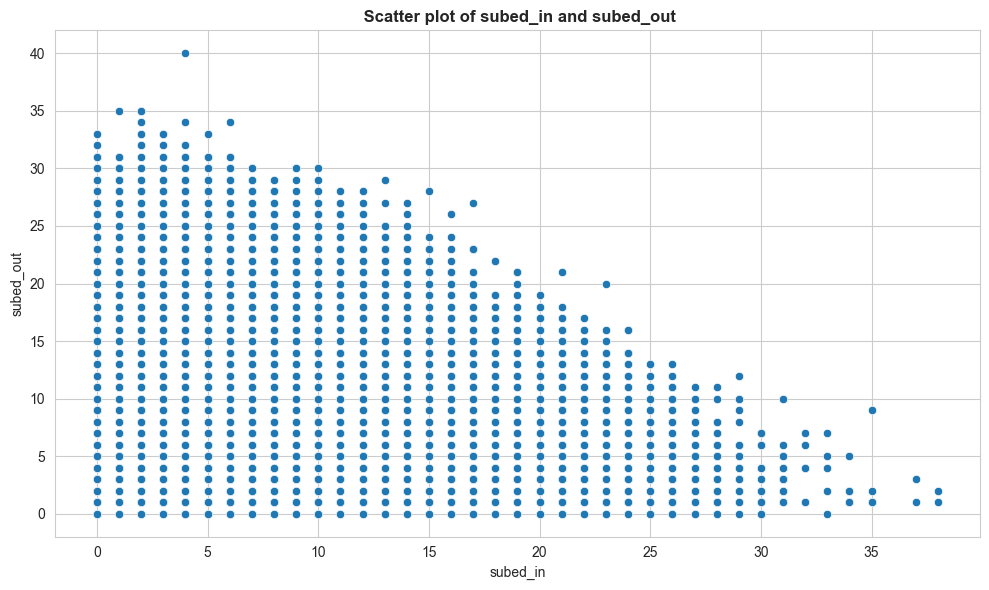

In [56]:
numerical_pair(df , 'subed_in' , 'subed_out')

In [57]:
df.columns

Index(['player_id', 'season_name', 'competition_name', 'team_name',
       'nb_in_group', 'nb_on_pitch', 'goals', 'assists', 'own_goals',
       'subed_in', 'subed_out', 'yellow_cards', 'second_yellow_cards',
       'direct_red_cards', 'penalty_goals', 'minutes_played', 'goals_conceded',
       'clean_sheets'],
      dtype='object')

> ### **Yellow Card Vs  Second Yellow card**

The Correlation   : 0.20


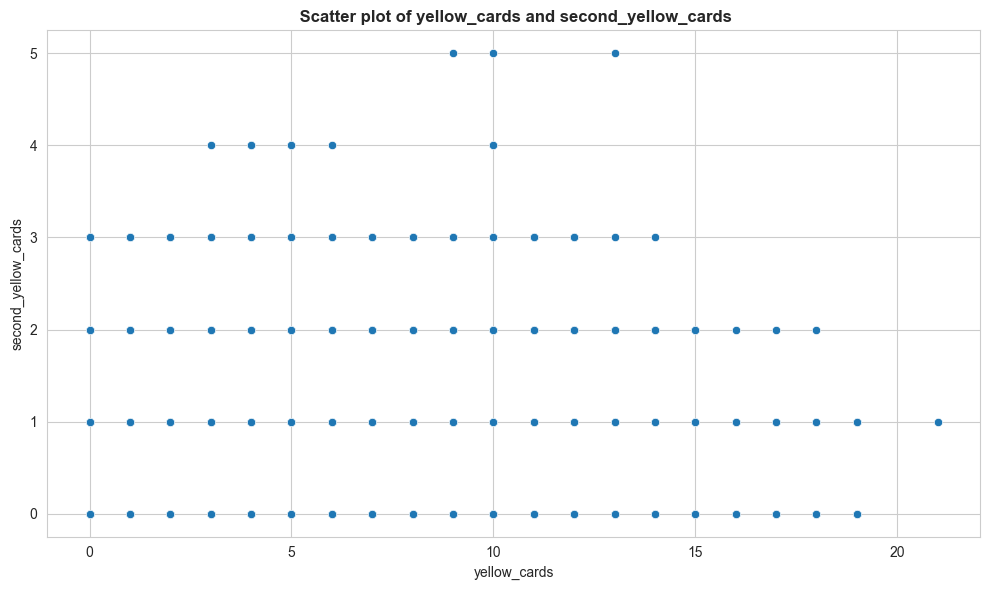

In [58]:
numerical_pair(df , 'yellow_cards', 'second_yellow_cards')

> ### **Yellow Card Vs Direct red Card**

The Correlation   : 0.15


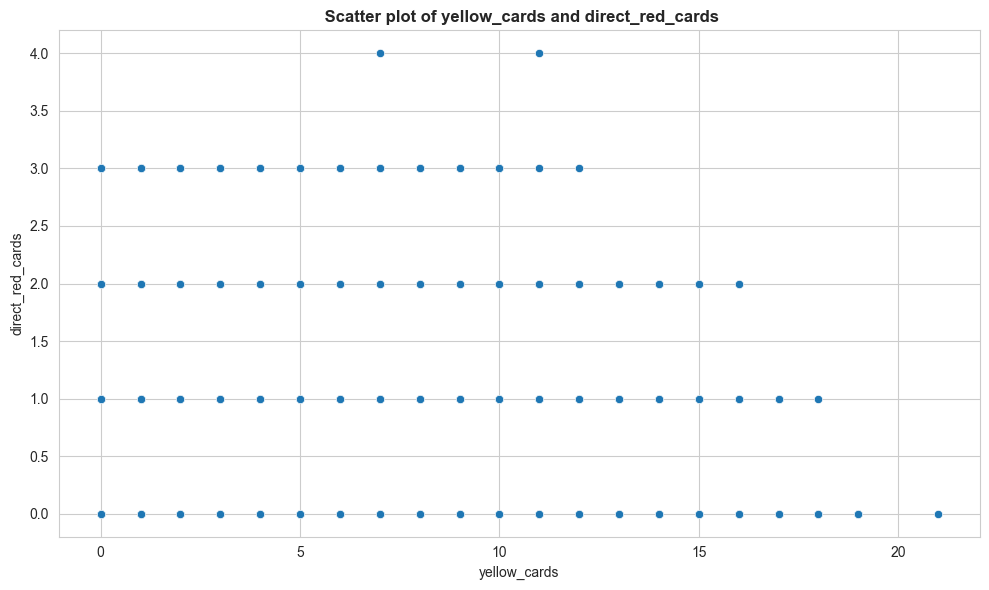

In [59]:
numerical_pair(df , 'yellow_cards','direct_red_cards')

> ### **Goals Vs Vs Min played**

The Correlation   : -0.28


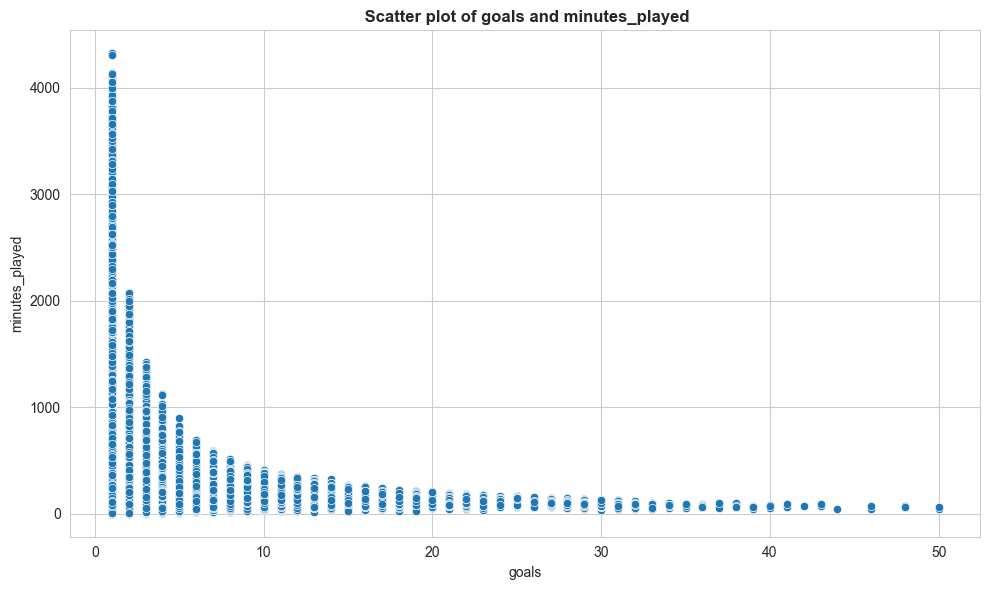

In [60]:
numerical_pair(df , 'goals' , 'minutes_played')

> ### **Second Yellow card Vs Dired red Card**

The Correlation   : 0.04


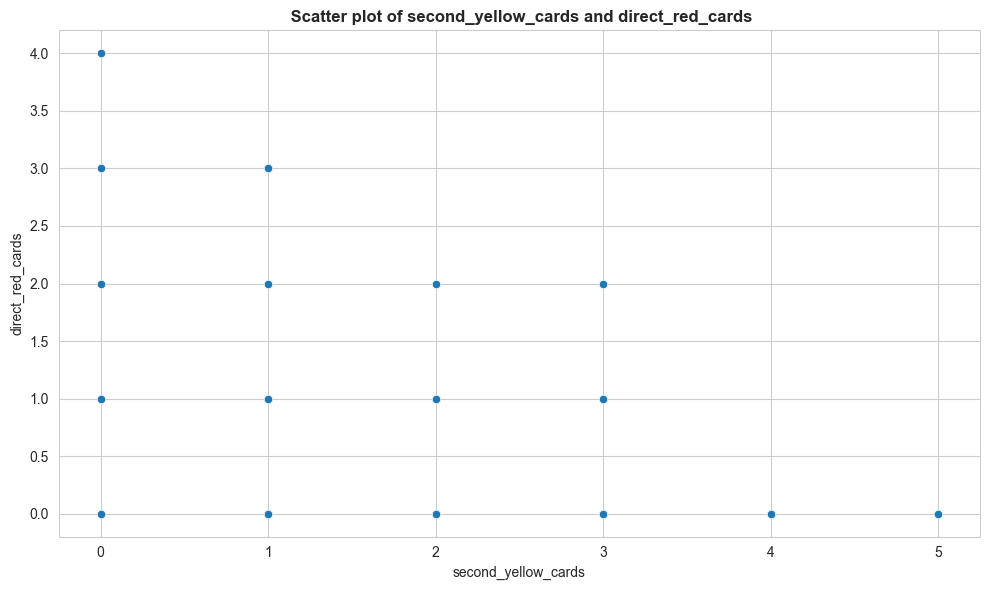

In [61]:
numerical_pair(df , 'second_yellow_cards','direct_red_cards')

> ### **Nb In Group Vs Nb On Pitch**

The Correlation   : 0.36


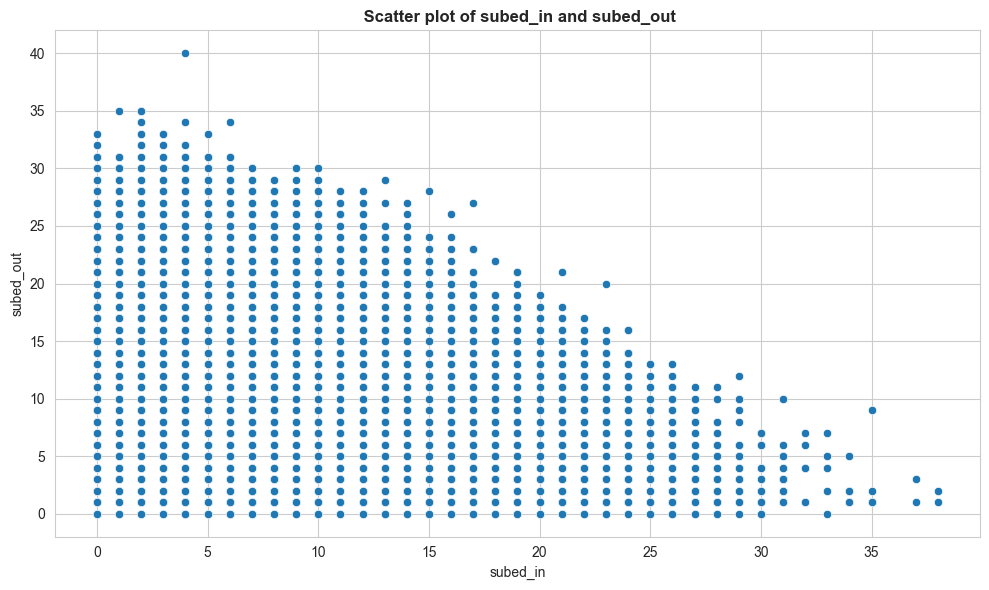

In [62]:
numerical_pair(df , 'subed_in', 'subed_out')

In [63]:
df.head(2)

,player_id,season_name,competition_name,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
1,1,07/08,Regionalliga Süd,FSV Ludwigshafen Oggersheim,22,22,1.0,0,0,3,8,1,0,0,0,1580.0,0,0
4,1,05/06,2. Bundesliga,SpVgg Unterhaching,26,14,1.0,1,0,12,1,1,0,0,0,388.0,0,0


#### **`Numerical Vs Categorical`**

In [64]:
df.head(2)

,player_id,season_name,competition_name,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
1,1,07/08,Regionalliga Süd,FSV Ludwigshafen Oggersheim,22,22,1.0,0,0,3,8,1,0,0,0,1580.0,0,0
4,1,05/06,2. Bundesliga,SpVgg Unterhaching,26,14,1.0,1,0,12,1,1,0,0,0,388.0,0,0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 570066 entries, 1 to 1878712
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   player_id            570066 non-null  int64  
 1   season_name          570066 non-null  object 
 2   competition_name     570066 non-null  object 
 3   team_name            570066 non-null  object 
 4   nb_in_group          570066 non-null  int64  
 5   nb_on_pitch          570066 non-null  int64  
 6   goals                570066 non-null  float64
 7   assists              570066 non-null  int64  
 8   own_goals            570066 non-null  int64  
 9   subed_in             570066 non-null  int64  
 10  subed_out            570066 non-null  int64  
 11  yellow_cards         570066 non-null  int64  
 12  second_yellow_cards  570066 non-null  int64  
 13  direct_red_cards     570066 non-null  int64  
 14  penalty_goals        570066 non-null  int64  
 15  minutes_played       

> ### Team Name and Goals

In [66]:
#Unique Team Name
df['team_name'].nunique()

12413

In [67]:
def cat_num_pair(df , cat_col, num_col):
    
    print(f"Statistics of {cat_col}")
    describe =df.groupby(cat_col)[num_col].sum().reset_index().sort_values(by=num_col,ascending=False)
    print(describe)

    
cat_num_pair(df , 'team_name', 'goals')    
    
    

Statistics of team_name
                        team_name   goals
8888                  Real Madrid  3427.0
3847                 FC Barcelona  3320.0
1267                   Arsenal FC  3290.0
7335            Manchester United  3186.0
1655                Bayern Munich  3095.0
...                           ...     ...
5284                     FV Lauda     1.0
3452           Dundee United FC B     1.0
7715              NK Jadran Porec     1.0
7707  NK Hrvatski vitez Posedarje     1.0
6607            Kalev Tallinn U21     1.0

[12413 rows x 2 columns]


> ### Competition Name and Goals

In [68]:
df['competition_name'].nunique()

1883

In [69]:
df['competition_name'].head(3)

1    Regionalliga Süd
4       2. Bundesliga
5     Oberliga Bayern
Name: competition_name, dtype: object

In [70]:
cat_num_pair(df , 'competition_name', 'goals')

Statistics of competition_name
              competition_name    goals
356               Championship  31606.0
1238            Premier League  30044.0
821                 League One  29908.0
251                 Bundesliga  28070.0
805                     LaLiga  24367.0
...                        ...      ...
1383  Relegation Kärntner Liga      1.0
1813       Uzbekistan Supercup      1.0
107          3 NAT PO Promotie      1.0
1881              ÖFB-Supercup      1.0
1882     ÖFB-Supercup (- 2005)      1.0

[1883 rows x 2 columns]


#### **`Categorical Vs Categorical`**

### **Team Name vs Competition Name**

In [71]:
def cat_cat_pair(df , col1, col2):
    
    """
    Analyze relationship between two categorical variables
    """
    crosstab = pd.crosstab(df[col1] , df[col2])
    print(crosstab)
    
cat_cat_pair(df, 'team_name' , 'competition_name')


competition_name                  1 Liga  1. CFL  1. CSFL  1. Division  \
team_name                                                                
07 Vestur                              0       0        0            0   
1. FC Brno                             0       0        0            0   
1. FC Eintracht Bamberg (- 2010)       0       0        0            0   
1. FC Lokomotive Leipzig               0       0        0            0   
1. FC Synot                            0       0        0            0   
...                                  ...     ...      ...          ...   
Ümraniyespor                           0       0        0            0   
Ümraniyespor Reserve                   0       0        0            0   
Ümraniyespor U19                       0       0        0            0   
Ünye 1957 Spor                         0       0        0            0   
Ünyespor                               0       0        0            0   

competition_name                  1. 

> # MultiVariate Analysis

#### **Correlation Matrix**

In [72]:
corr = df.select_dtypes(include=[np.number]).corr()
corr

,player_id,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
player_id,1.000000,-0.085850,-0.092263,-0.056589,-0.047852,-0.018775,0.052979,0.038683,-0.089790,-0.040557,-0.038887,-0.050203,-0.061294,NaN,NaN
nb_in_group,-0.085850,1.000000,0.972807,0.389013,0.397490,0.121761,0.456847,0.584491,0.618017,0.156320,0.144286,0.156188,0.517218,NaN,NaN
nb_on_pitch,-0.092263,0.972807,1.000000,0.438795,0.428863,0.123618,0.380324,0.603835,0.646677,0.164676,0.151831,0.185357,0.523340,NaN,NaN
goals,-0.056589,0.389013,0.438795,1.000000,0.380226,-0.014525,0.078315,0.411173,0.208305,0.036175,0.050543,0.523075,-0.276031,NaN,NaN
assists,-0.047852,0.397490,0.428863,0.380226,1.000000,-0.001357,0.104570,0.403652,0.236857,0.026937,0.027059,0.201586,0.059547,NaN,NaN
own_goals,-0.018775,0.121761,0.123618,-0.014525,-0.001357,1.000000,-0.037499,-0.032547,0.121168,0.039536,0.039459,-0.009184,0.163497,NaN,NaN
subed_in,0.052979,0.456847,0.380324,0.078315,0.104570,-0.037499,1.000000,0.357079,0.071383,-0.011699,0.004317,-0.027434,-0.009038,NaN,NaN
subed_out,0.038683,0.584491,0.603835,0.411173,0.403652,-0.032547,0.357079,1.000000,0.311818,0.034487,0.034404,0.157791,0.084579,NaN,NaN
yellow_cards,-0.089790,0.618017,0.646677,0.208305,0.236857,0.121168,0.071383,0.311818,1.000000,0.198623,0.146770,0.119246,0.464881,NaN,NaN
second_yellow_cards,-0.040557,0.156320,0.164676,0.036175,0.026937,0.039536,-0.011699,0.034487,0.198623,1.000000,0.041899,0.020649,0.145923,NaN,NaN


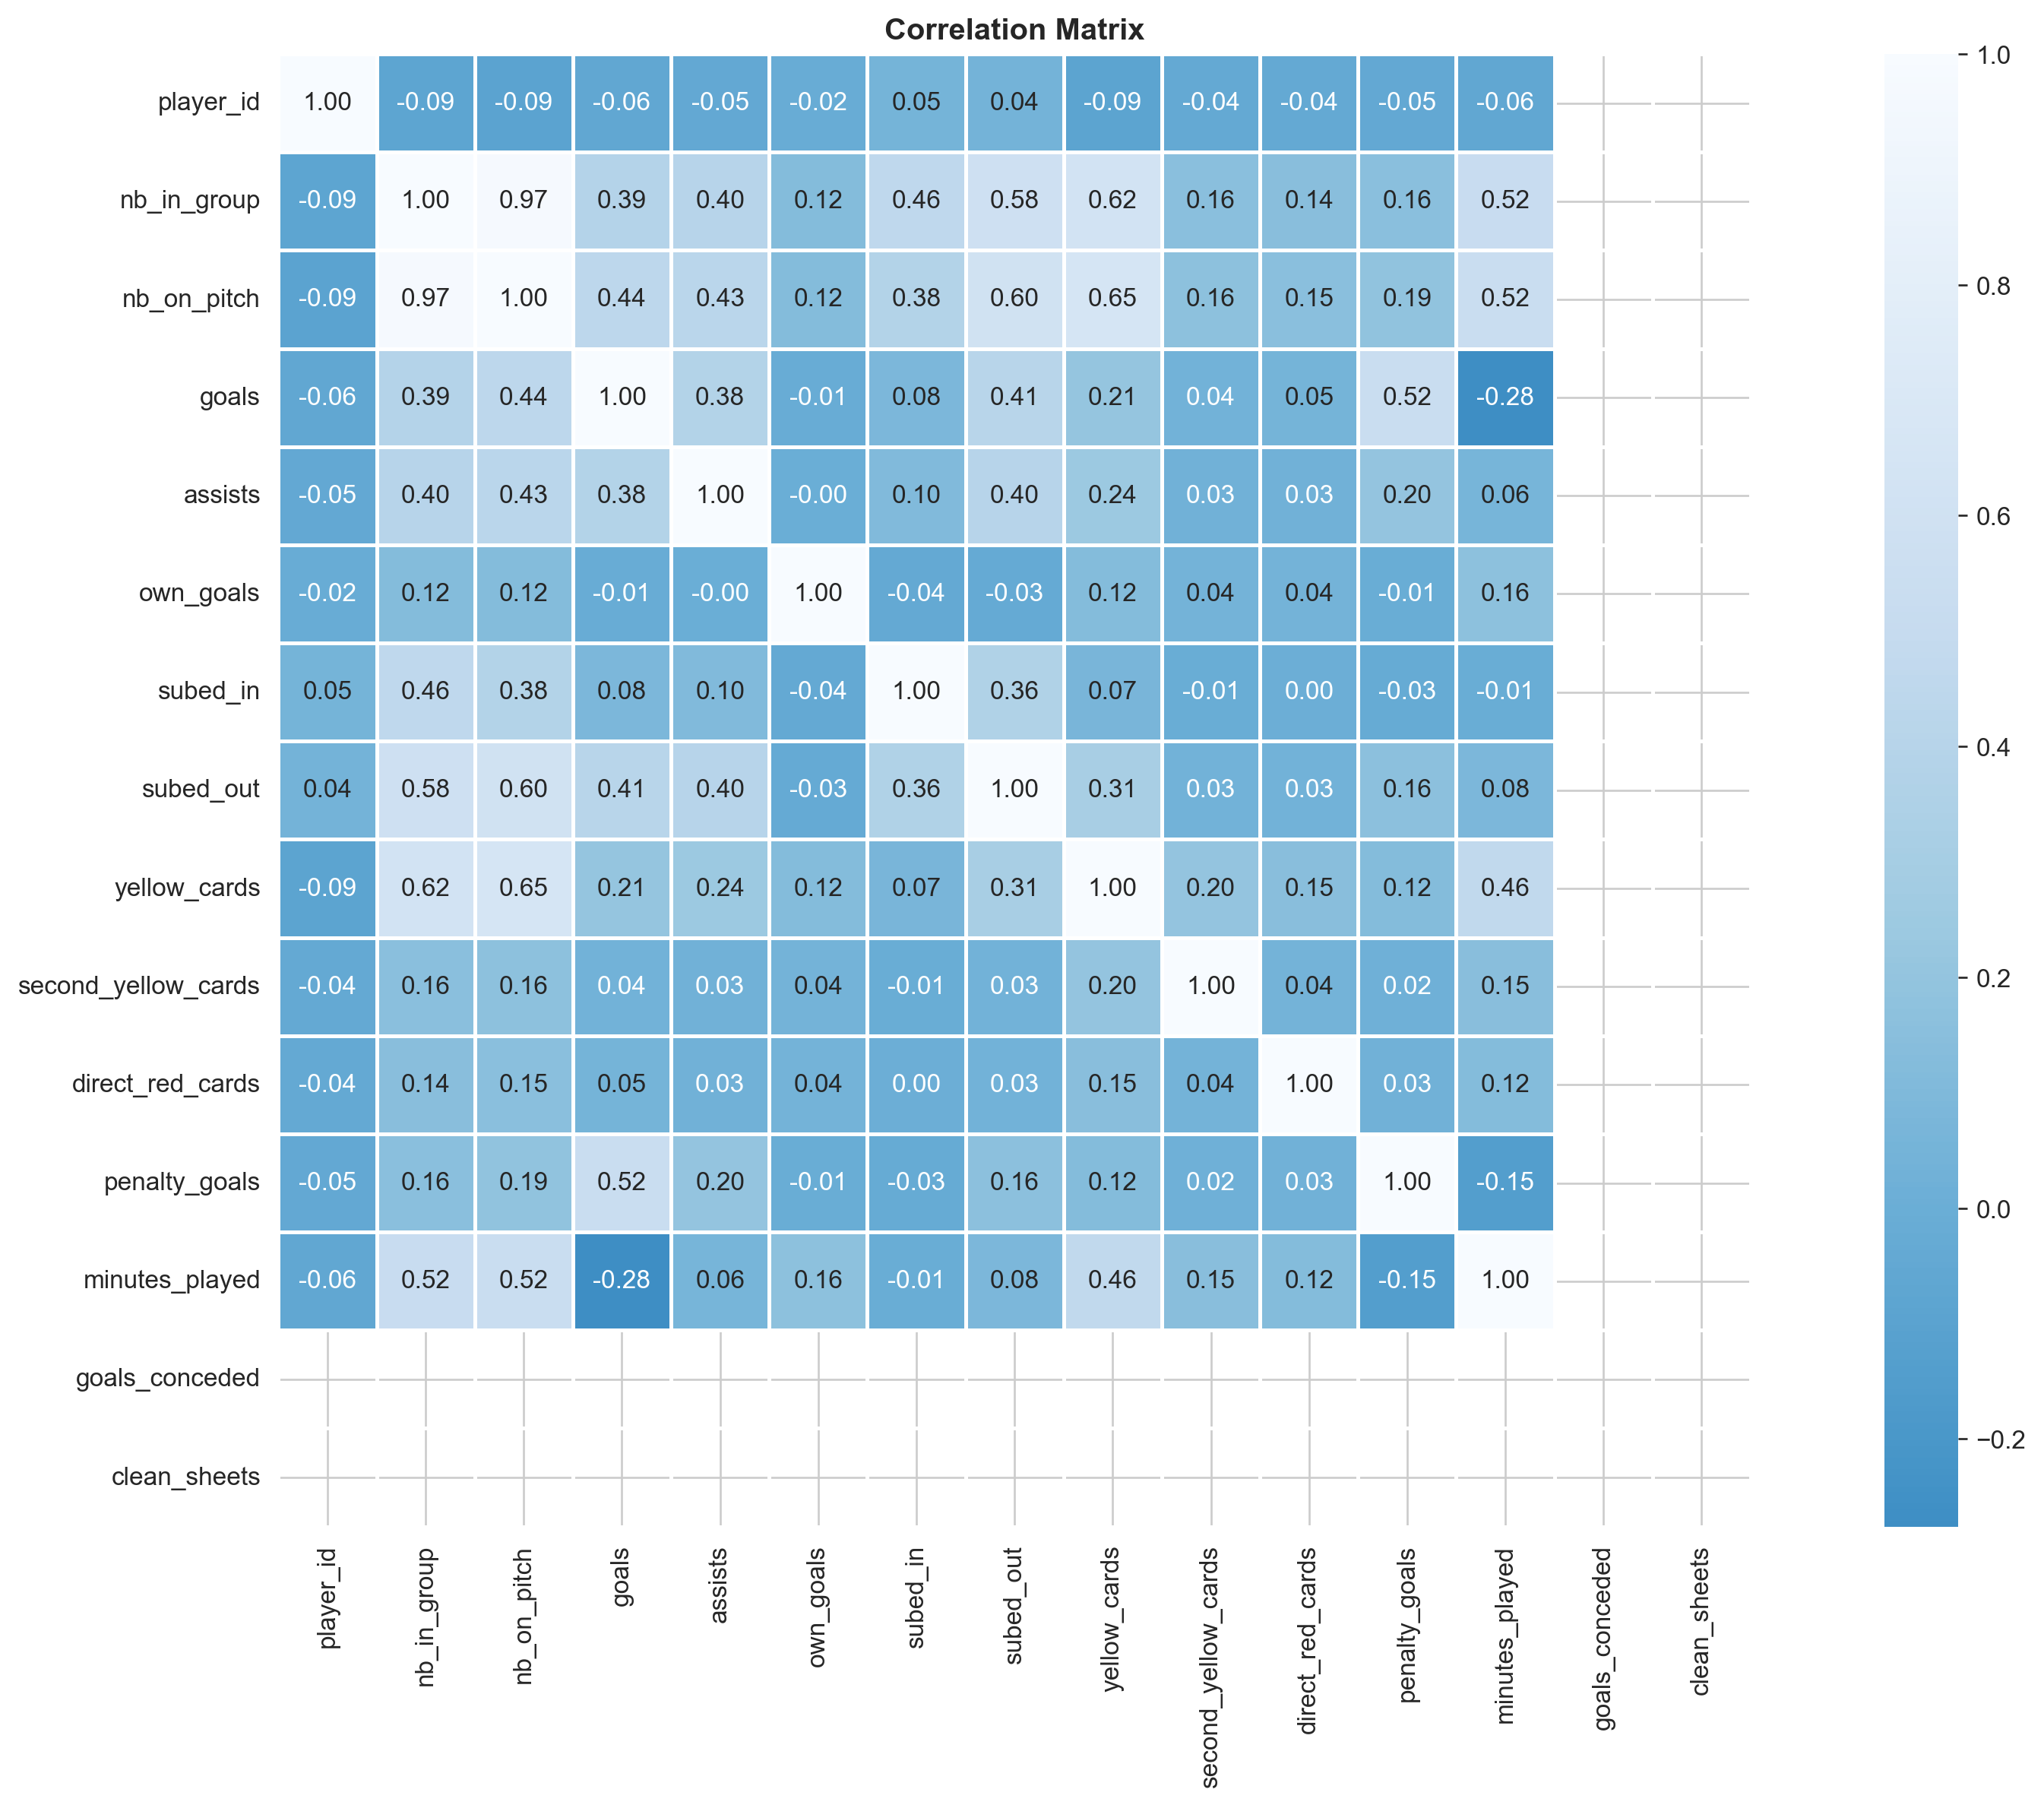

In [73]:
plt.figure(figsize=(15,10), dpi=240)

sns.heatmap(corr , annot=True, fmt=".2f",cmap='Blues_r' , center=0 ,square=True , linewidths=1)
plt.title('Correlation Matrix' , weight='bold')
plt.tight_layout()
plt.show()

> ## **PCA Analysis**

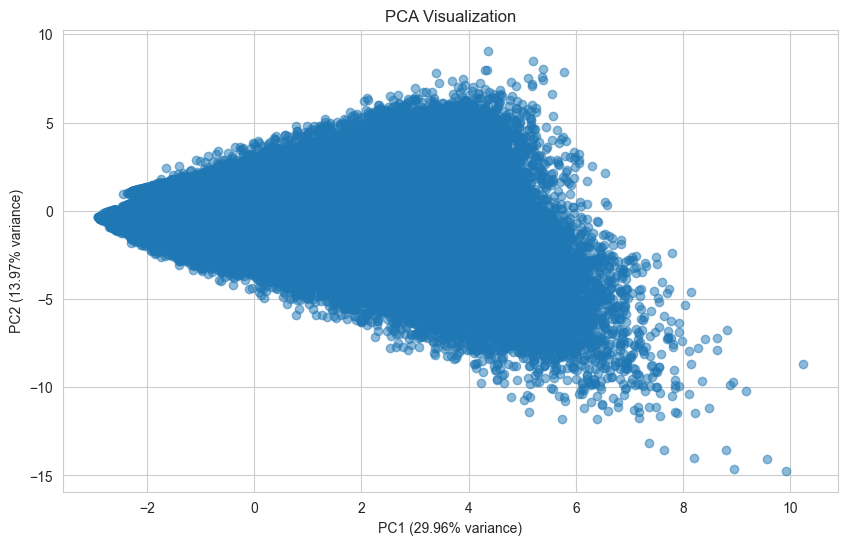

In [74]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


numeric_df = df.select_dtypes(include=[np.number]).dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)


pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)


plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA Visualization')
plt.show()

> # **`Questions`**

1. **Top 5 club based on Goals**

2. **Top 5 Competition based on Assists**

3. **Top 5 Competition based on Goals**

4. **Top 5 club based on Asissts**

5. **Top 2 Season Based On goals**

6. **Top 5 Team by Red Card**

11. **Which teams Has most Goal ratio**

12. **Which competitions (competition_name) exhibit the highest density of yellow and red cards per minute played?**

13. **What is the relationship between a team's average minutes_played per player and their total clean_sheets in a season?**

 ****


> 1. **Top 5 club based on Goals**

In [77]:
#Top 5 club by goal

df.groupby('team_name')['goals'].sum().reset_index().sort_values(by='goals', ascending=False).head(5)

,team_name,goals
8888,Real Madrid,3427.0
3847,FC Barcelona,3320.0
1267,Arsenal FC,3290.0
7335,Manchester United,3186.0
1655,Bayern Munich,3095.0


> **Top 5 Competition based on Goals**

In [79]:
#Top 5 Competition by goal

df.groupby('competition_name')['goals'].sum().reset_index().sort_values(by='goals', ascending=False).head(5)

,competition_name,goals
356,Championship,31606.0
1238,Premier League,30044.0
821,League One,29908.0
251,Bundesliga,28070.0
805,LaLiga,24367.0


In [78]:
df.columns

Index(['player_id', 'season_name', 'competition_name', 'team_name',
       'nb_in_group', 'nb_on_pitch', 'goals', 'assists', 'own_goals',
       'subed_in', 'subed_out', 'yellow_cards', 'second_yellow_cards',
       'direct_red_cards', 'penalty_goals', 'minutes_played', 'goals_conceded',
       'clean_sheets'],
      dtype='object')

>  **Top 5 club based on Asissts**

In [80]:
df.groupby('team_name')['assists'].sum().reset_index().sort_values(by='assists', ascending=False).head(5)

,team_name,assists
8888,Real Madrid,2263
1655,Bayern Munich,2222
3847,FC Barcelona,2168
7335,Manchester United,1929
1267,Arsenal FC,1875


> **Top 5 Competition based on Assists**

In [81]:
df.groupby('competition_name')['assists'].sum().reset_index().sort_values(by='assists', ascending=False).head(5)

,competition_name,assists
251,Bundesliga,20116
356,Championship,19073
1238,Premier League,17325
821,League One,16052
805,LaLiga,13561


>  **Top 2 Season Based On goals**

In [83]:
df.groupby('season_name')['goals'].sum().reset_index().sort_values(by='goals', ascending=False).head(2)

,season_name,goals
64,22/23,92706.0
65,23/24,91519.0


>  **Top 5 Team by Direct Red Card**

In [90]:
df.groupby('team_name')['direct_red_cards'].sum().reset_index().sort_values(by='direct_red_cards', ascending=False).head(5)

,team_name,direct_red_cards
10746,São Paulo Futebol Clube,75
3276,Deportivo Guadalajara,74
2324,CF América,71
10496,Sport Club Internacional,71
1267,Arsenal FC,70


> **Which teams Has most Goal ratio**

In [103]:
df.groupby('team_name').agg({
    'goals': 'sum',
    'minutes_played': 'sum'
}).reset_index().sort_values(by=['goals', 'minutes_played'], ascending=[False, True]).head(5)

,team_name,goals,minutes_played
8888,Real Madrid,3427.0,394287.0
3847,FC Barcelona,3320.0,400333.0
1267,Arsenal FC,3290.0,568710.0
7335,Manchester United,3186.0,502503.0
1655,Bayern Munich,3095.0,393723.0
